<a href="https://colab.research.google.com/github/kassingit/IA-EMBARQUEE/blob/main/TP1_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab1 — Foundations of Machine Learning & Linear Regression
**Polytech Nice Sophia — Embedded Artificial Intelligence**

---

> **Instructions:** Complete every cell marked with `# ── TODO ──`.

| Info | Detail |
|------|--------|
| **Duration** | ~1 hours |
| **Tools** | Python 3, NumPy, Matplotlib, scikit-learn |

## Learning Objectives

By the end of this session you will be able to:

1. Define Machine Learning and distinguish **Classification** from **Regression**.
2. Identify the three types of learning: **Supervised**, **Unsupervised**, **Reinforcement**.
3. Understand the ML pipeline: training set, test set, and **generalization**.
4. Implement **linear regression** and **gradient descent** from scratch with NumPy.
5. Compute and interpret **RMSE** and **MAE** loss functions.
6. Identify **overfitting** and **underfitting** from learning curves.

## How to use this notebook

To execute the code inside this notebook, you have two options :

### 1) Localy

1. Open a terminal in your working directory.
2. Type **python -m venv lab_venv** to create a python environment (can also be **python3 -m venv lab_venv**).
3. Type **./lab_venv/Scripts/Activate.ps1** for Windows and **source lab_venv/bin/activate** for Linux.
4. Type **pip install -q numpy matplotlib scikit-learn ipykernel**.
5. Select this environment (lab_venv) as your kernel in the top-right corner of VS Code. To do so, open your working directory as a folder in VS Code; if you only open the individual file, the virtual environment will not appear.

### 2) Google colab

1. Go to <a href="https://colab.research.google.com/">Google colab</a>.
2. Import and open this notebook.
3. Disable the auto completion (Tools -> Settings -> AI assistance -> uncheck "Show AI-powered inline completions" and "Consented to use generative AI features").
4. If some libraries are missing, uncomment the second line of the cell below.

In [ ]:
# ── Setup ────────────────────────────────────────────────────────────────────
# !pip install -q numpy matplotlib scikit-learn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error

np.random.seed(42)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    plt.style.use("seaborn-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 12
print("Libraries loaded successfully!")

Libraries loaded successfully!


---
## Section 1 — Course Reminders

### 1.1 What is Machine Learning?

> **Machine Learning** is *"the science of programming computers to learn from data."*
> — Aurélien Géron, *Hands-On Machine Learning*

Instead of writing explicit rules, we **show data to an algorithm** and let it discover rules by itself.

### 1.2 Categories of ML Tasks

| Task | Output | Example |
|------|--------|---------|
| **Classification** | A label from a finite set | Spam detection (spam / not spam) |
| **Regression** | A continuous number | House price prediction |

### 1.3 The Three Types of Learning

#### Supervised Learning
The training set contains **labeled examples** $(x^{(i)}, y^{(i)})$.

Goal: learn $h : x \to y$. Example: image classification with pre-labeled data.

#### Unsupervised Learning
Training set has **no labels**.

Goal: discover structure (clusters, patterns). Example: grouping customers by purchasing behaviour.

#### Reinforcement Learning
An **agent** takes actions in an environment and receives **rewards** or **penalties**.

Goal: learn a strategy that maximises cumulative rewards. Example: AlphaGo.

### 1.4 The Train/Test Split

| Split | Percentage | Used for |
|-------|-----------|---------|
| **Training set** | 70–80 % | Fitting the model parameters |
| **Test set** | 20–30 % | Final evaluation — *never seen during training* |

Evaluating on training data alone gives an **optimistically biased** estimate!

### 1.5 Loss Functions: RMSE and MAE

#### Mean Absolute Error (MAE) — $\ell_1$ norm
$$\text{MAE} = \frac{1}{m}\sum_{i=1}^{m} \left|y^{(i)} - \hat{y}^{(i)}\right|$$

#### Root Mean Square Error (RMSE) — $\ell_2$ norm
$$\text{RMSE} = \sqrt{\frac{1}{m}\sum_{i=1}^{m} \left(y^{(i)} - \hat{y}^{(i)}\right)^2}$$

### 1.6 Linear Regression & Gradient Descent

The linear model predicts: $\hat{y} = w \cdot x + b$

Update rules:
$$w \leftarrow w - \eta \cdot \frac{\partial \mathcal{L}}{\partial w}, \qquad b \leftarrow b - \eta \cdot \frac{\partial \mathcal{L}}{\partial b}$$

### 1.7 Bias–Variance Tradeoff

| Problem | Training error | Test error |
|---------|----------------|------------|
| Underfitting (High Bias) | High | High |
| Good fit | Low | Low |
| Overfitting (High Variance) | Very low | High |



### 1.8 Workflow of machine learning training



<center>
<div>
<img src="img/workflow.png" alt="There are six steps that will be explored during this lab session : Dataset, prediction model, inference, metrics, loss function and weight update" width="900"/>
</div>
</center>

## Section 2 — Experiments

---


### Step 1: Generate & Visualise a Synthetic Dataset

#### Focus of the exercice :
<center>
<div>
<img src="img/step1.png", alt ="Dataset" width="500"/>
</div>
</center>

**Your task:** complete the line that generates `y` (predictions + Gaussian noise).

We want to generate a noisy dataset following:
$$y = 2x + 1 + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2)$$



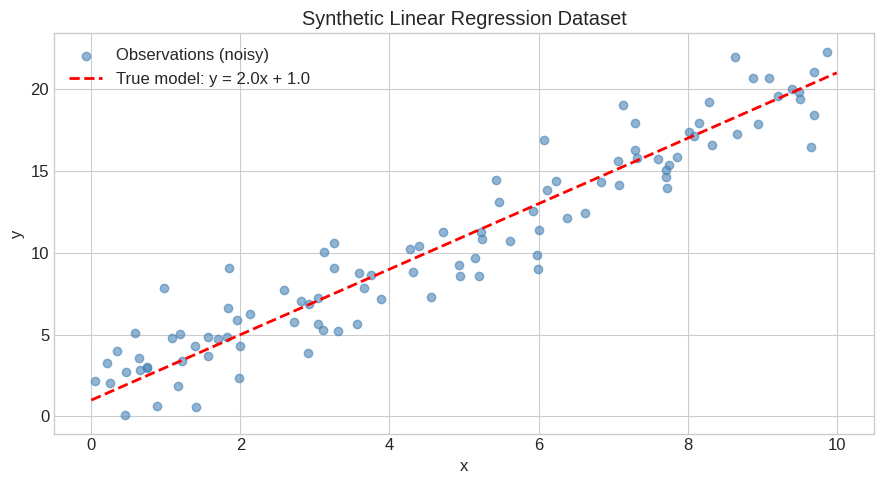

Samples: 100  |  True w=2.0, b=1.0  |  Noise σ=2.0


In [ ]:
# ── Step 1: Generate the synthetic dataset ────────────────────────────────────
n_samples = 100
true_w, true_b = 2.0, 1.0
noise_std = 2.0

# Input features: uniformly sampled in [0, 10]
X = np.random.uniform(0, 10, n_samples)

# ── TODO ─────────────────────────────────────────────────────────────────────
# Generate noisy target y = true_w * X + true_b + Gaussian noise
# Hint: np.random.normal(mean, std, size) generates Gaussian noise
# y = ...
# ─────────────────────────────────────────────────────────────────────────────

# >>> Replace the line below with your code:
#raise NotImplementedError("Step 1 — TODO: generate y")
noise = np.random.normal(0, noise_std, n_samples)

y = true_w * X + true_b + noise

# Visualise (run after completing y above)
x_line = np.linspace(0, 10, 200)
plt.figure(figsize=(9, 5))
plt.scatter(X, y, alpha=0.6, color="steelblue", label="Observations (noisy)")
plt.plot(x_line, true_w * x_line + true_b, "r--", lw=2,
         label=f"True model: y = {true_w}x + {true_b}")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Synthetic Linear Regression Dataset")
plt.legend(); plt.tight_layout(); plt.show()
print(f"Samples: {n_samples}  |  True w={true_w}, b={true_b}  |  Noise σ={noise_std}")

### Step 2: Manual Gradient Descent (1-parameter model)



#### Focus of the exercice :
<center>
<div>
<img src="img/step2.png" alt="Forward pass, loss function and backward pass" width="500"/>
</div>
</center>

We train a simplified model $\hat{y} = w \cdot x$ (slope only, no bias).

The MSE loss and its gradient are:
$$\mathcal{L}(w) = \frac{1}{m}\sum (y^{(i)} - wx^{(i)})^2$$
$$\frac{\partial \mathcal{L}}{\partial w} = \frac{-2}{m}\sum x^{(i)}(y^{(i)} - wx^{(i)})$$


<div>
</div>

**Your tasks (4 lines to complete):**
1. Compute predictions `y_pred`
2. Compute `residuals` (true - predicted)
3. Compute `loss` (MSE formula)
4. Compute the `gradient` (formula above)
5. Apply the weight **update rule** to `w`

Learned w = 2.1259  (true: 2.0)
Final MSE = 3.8069


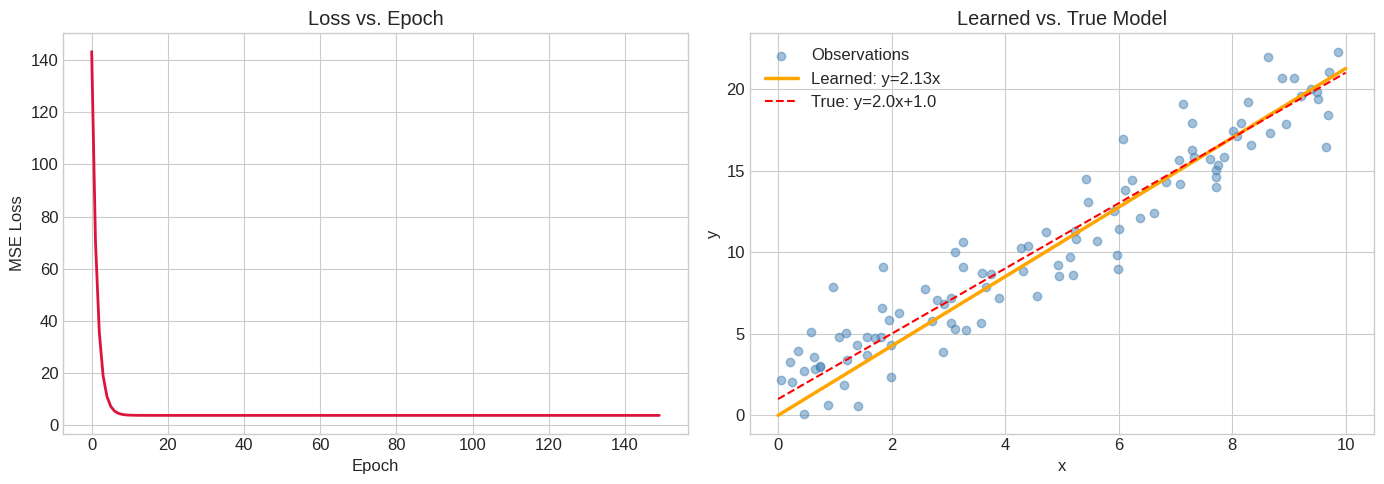

In [ ]:
# ── Step 2: Manual Gradient Descent – 1 parameter (slope only) ───────────────
learning_rate = 0.005
n_epochs      = 150
w             = 0.0      # initialise weight to 0
loss_history  = []

for epoch in range(n_epochs):
    # ── TODO ──────────────────────────────────────────────────────────────────
    # 1. Compute model predictions (linear model without bias)
    #    y_pred = ?
    y_pred = w * X # ← replace

    # 2. Compute residuals: difference between true y and predicted y
    #    residuals = ?
    residuals = y - y_pred   # ← replace

    # 3. Compute the MSE loss = mean of squared residuals
    #    loss = ?
    loss = np.mean((y - y_pred)**2)   # ← replace

    # 4. Compute the gradient dL/dw = -2/m * sum(X * residuals)
    #    gradient = ?
    gradient = -2/n_samples * np.sum(X * residuals)   # ← replace // m = n_samples

    # 5. Update the weight: w = w - learning_rate * gradient
    #    w = ?
    #    (do NOT write w -= ... yet, write it out fully)
    w = w - learning_rate * gradient
    # ──────────────────────────────────────────────────────────────────────────

    loss_history.append(loss)

print(f"Learned w = {w:.4f}  (true: {true_w})")
print(f"Final MSE = {loss_history[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(loss_history, color="crimson", lw=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Loss vs. Epoch")
axes[1].scatter(X, y, alpha=0.5, color="steelblue", label="Observations")
axes[1].plot(x_line, w * x_line, "orange", lw=2.5, label=f"Learned: y={w:.2f}x")
axes[1].plot(x_line, true_w * x_line + true_b, "r--", lw=1.5,
             label=f"True: y={true_w}x+{true_b}")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
axes[1].set_title("Learned vs. True Model"); axes[1].legend()
plt.tight_layout(); plt.show()

### Step 3: Full Linear Model — Slope + Bias, RMSE & MAE



#### Focus of the exercice :
<center>
<div>
<img src="img/step2.png" alt="Forward pass, loss function and backward pass" width="500"/>
</div>
</center>

Now we add a bias term: $\hat{y} = wx + b$.

The two gradients become:
$$\frac{\partial \mathcal{L}}{\partial w} = \frac{-2}{m}\sum x^{(i)}(y^{(i)}-\hat{y}^{(i)}), \qquad
  \frac{\partial \mathcal{L}}{\partial b} = \frac{-2}{m}\sum (y^{(i)}-\hat{y}^{(i)})$$

**Your tasks:**
- Implement `rmse()` and `mae()` functions
- Add the bias `b` to the model and update `dw`, `db`

Learned  w=1.9822  b=0.9474  (true: w=2.0, b=1.0)
Train RMSE = 1.8145
Train MAE  = 1.4439


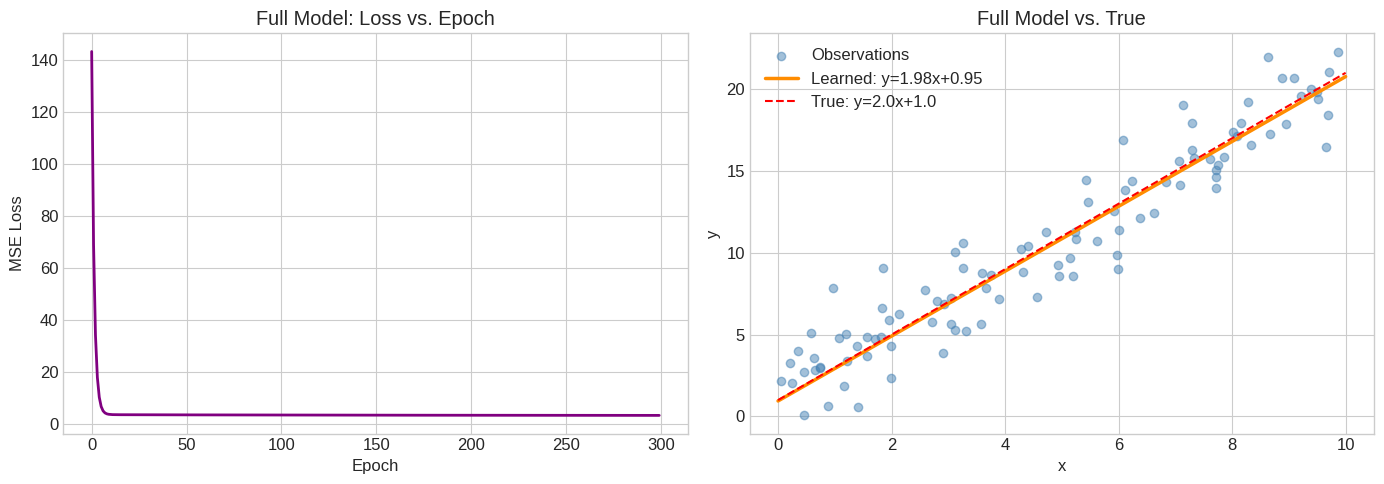

In [ ]:
# ── Step 3: Full linear model with slope and bias ─────────────────────────────

# ── TODO: implement the two metric functions ──────────────────────────────────
def rmse(y_true, y_pred):
    '''Root Mean Squared Error -- RMSE = sqrt(mean((y_true - y_pred)^2))'''
    # Hint: use np.sqrt and np.mean
    # return ...
    #raise NotImplementedError("TODO: implement RMSE")
    return np.sqrt(np.mean((y_true - y_pred)**2))


def mae(y_true, y_pred):
    '''Mean Absolute Error -- MAE = mean(|y_true - y_pred|)'''
    # Hint: use np.abs and np.mean
    # return ...
    # raise NotImplementedError("TODO: implement MAE")
    return np.mean(np.abs(y_true - y_pred))
# ─────────────────────────────────────────────────────────────────────────────

lr_rate  = 0.005
n_epochs = 300
w, b     = 0.0, 0.0
history  = []

for _ in range(n_epochs):
    # ── TODO ──────────────────────────────────────────────────────────────────
    # 1. Compute predictions with bias: y_pred = w * X + b
    y_pred = w * X + b   # ← replace

    # 2. Residuals
    residuals = y - y_pred   # ← replace

    # 3. Record MSE loss
    history.append(np.mean((y - y_pred)**2))   # ← replace None with loss expression

    # 4. Compute gradients dw and db (see formulas above)
    dw = -2*np.mean(X*(y - y_pred))   # ← replace
    db = -2*np.mean(y - y_pred)   # ← replace
    #dw = -2/n_samples * np.sum(X * residuals)
    #dl = -2/n_samples * np.sum(residuals)

    # 5. Update both parameters
    # w -= ...
    # b -= ...
    w = w - learning_rate * dw
    b = b - learning_rate * db


    # ──────────────────────────────────────────────────────────────────────────

y_pred_final = w * X + b
print(f"Learned  w={w:.4f}  b={b:.4f}  (true: w={true_w}, b={true_b})")
print(f"Train RMSE = {rmse(y, y_pred_final):.4f}")
print(f"Train MAE  = {mae(y,  y_pred_final):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history, color="purple", lw=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Full Model: Loss vs. Epoch")
axes[1].scatter(X, y, alpha=0.5, color="steelblue", label="Observations")
axes[1].plot(x_line, w * x_line + b, "darkorange", lw=2.5,
             label=f"Learned: y={w:.2f}x+{b:.2f}")
axes[1].plot(x_line, true_w * x_line + true_b, "r--", lw=1.5,
             label=f"True: y={true_w}x+{true_b}")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
axes[1].set_title("Full Model vs. True"); axes[1].legend()
plt.tight_layout(); plt.show()

### Step 4: Train / Test Split



#### Focus of the exercice :
<center>
<div>
<img src="img/step4.png" alt="Dataset and metrics" width="500"/>
</div>
</center>

We now split the dataset **before** fitting the model.
When training is done, we **test** the model on the remaining data, unseen during training.
A large gap between training and test errors signals **overfitting**.

Train: 70 samples  |  Test: 30 samples

Model: w=1.9067, b=1.2358

Metric        Train       Test
------------------------------
RMSE         1.8934     1.5886
MAE          1.5165     1.1947


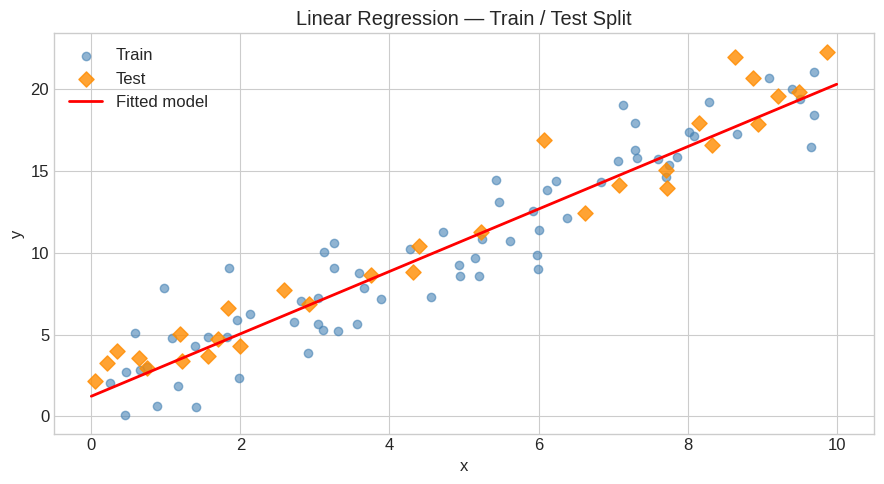

In [ ]:
# ── Step 4: Train / Test Split ────────────────────────────────────────────────
X2d = X.reshape(-1, 1)
X_tr, X_te, y_tr, y_te = train_test_split(X2d, y, test_size=0.30, random_state=42)
print(f"Train: {len(X_tr)} samples  |  Test: {len(X_te)} samples")

# We use sklearn's LinearRegression here as a reference solver
lr = LinearRegression().fit(X_tr, y_tr)
y_tr_pred = lr.predict(X_tr)
y_te_pred = lr.predict(X_te)

# ── TODO ──────────────────────────────────────────────────────────────────────
# Use your rmse() and mae() functions (from Step 3) to compute the errors:
#   train_rmse, test_rmse, train_mae, test_mae
train_rmse = rmse(y_tr,y_tr_pred)   # ← replace
test_rmse  = rmse(y_te,y_te_pred)   # ← replace
train_mae  = mae(y_tr,y_tr_pred)   # ← replace
test_mae   = mae(y_te,y_te_pred)   # ← replace
# ─────────────────────────────────────────────────────────────────────────────

print(f"\nModel: w={lr.coef_[0]:.4f}, b={lr.intercept_:.4f}")
print(f"\n{'Metric':<8} {'Train':>10} {'Test':>10}")
print("-" * 30)
print(f"{'RMSE':<8} {train_rmse:>10.4f} {test_rmse:>10.4f}")
print(f"{'MAE':<8} {train_mae:>10.4f} {test_mae:>10.4f}")

plt.figure(figsize=(9, 5))
plt.scatter(X_tr, y_tr, alpha=0.6, color="steelblue", label="Train")
plt.scatter(X_te, y_te, alpha=0.8, color="darkorange", marker="D", s=60, label="Test")
x_plot = np.linspace(0, 10, 200).reshape(-1, 1)
plt.plot(x_plot, lr.predict(x_plot), "red", lw=2, label="Fitted model")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Linear Regression — Train / Test Split")
plt.legend(); plt.tight_layout(); plt.show()

### Step 5: Overfitting Demo — Polynomial Regression



We fit polynomial models of increasing degree to a *small* dataset.

> **Observe:** as degree grows, training error ↓ but test error ↑. This is **overfitting**.

**Bonus question:** For which degree is the model best? Why?

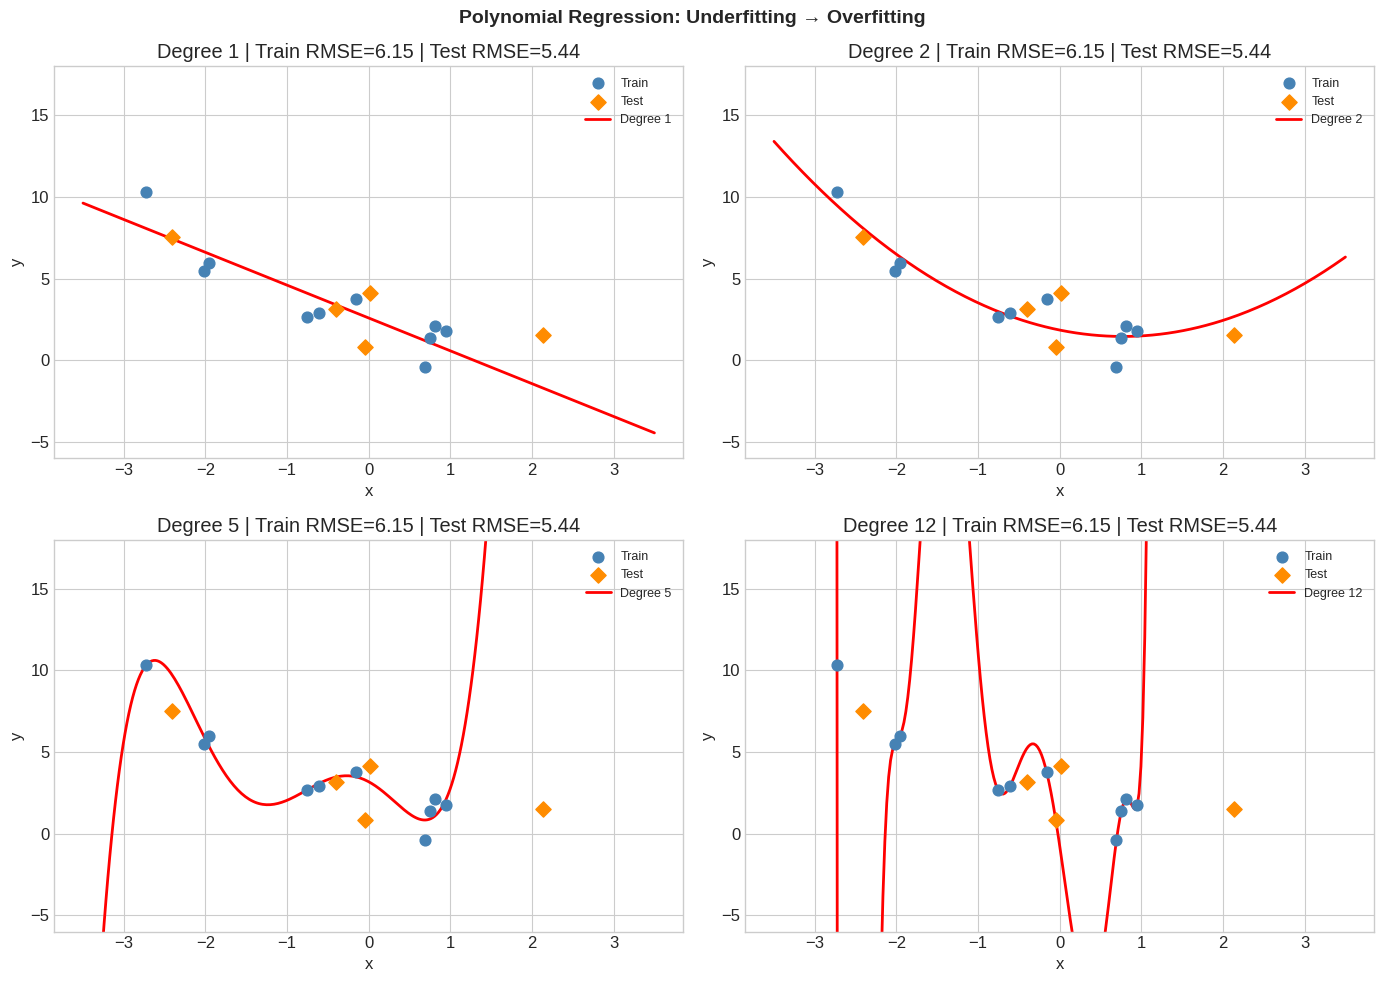

📌 Degree 1: underfitting.  Degree 2: good fit.  Degree 5–12: overfitting.


In [ ]:
# ── Step 6: Overfitting Demo ─────────────────────────────────────────────────
n_small = 15
X_s = np.sort(np.random.uniform(-3, 3, n_small))
y_s = 0.5 * X_s**2 - X_s + 2 + np.random.normal(0, 1.0, n_small)
X_s2d = X_s.reshape(-1, 1)
X_str, X_ste, y_str, y_ste = train_test_split(X_s2d, y_s, test_size=0.3, random_state=0)

#================== ADDED BY MYSELF : ADAPTATION NEEDED FOR THE DEGREE IS 2 ==========================
lrs = LinearRegression().fit(X_str, y_str)
y_str_pred = lr.predict(X_str)
y_ste_pred = lr.predict(X_ste)
#=============================================================

x_plot = np.linspace(-3.5, 3.5, 300).reshape(-1, 1)
degrees = [1, 2, 5, 12]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, deg in zip(axes.flatten(), degrees):
    model = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    model.fit(X_str, y_str)

    # ── TODO ──────────────────────────────────────────────────────────────────
    # Compute training and test RMSE using your rmse() function
    tr_err = rmse(y_str,y_str_pred)   # ← replace
    te_err = rmse(y_ste,y_ste_pred)   # ← replace
    # ──────────────────────────────────────────────────────────────────────────

    ax.scatter(X_str, y_str, color="steelblue",  s=60, label="Train", zorder=3)
    ax.scatter(X_ste, y_ste, color="darkorange", s=60, marker="D", label="Test", zorder=3)
    ax.plot(x_plot, model.predict(x_plot), "red", lw=2, label=f"Degree {deg}")
    ax.set_ylim(-6, 18)
    ax.set_title(f"Degree {deg} | Train RMSE={tr_err:.2f} | Test RMSE={te_err:.2f}")
    ax.legend(fontsize=9); ax.set_xlabel("x"); ax.set_ylabel("y")

plt.suptitle("Polynomial Regression: Underfitting → Overfitting", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()
print("📌 Degree 1: underfitting.  Degree 2: good fit.  Degree 5–12: overfitting.")

### Step 6: Comparison — Manual GD vs. scikit-learn

> **Expected result:** both methods should find very similar parameters ($w \approx 2$, $b \approx 1$).
> If your values are very different, re-check the gradient formulas in Step 3.

=== Your Manual Gradient Descent (Step 3) ===
  w=1.982248  b=0.947412
  RMSE=1.814527  MAE=1.443919

=== scikit-learn LinearRegression (Normal Equation) ===
  w=1.908045  b=1.430192
  RMSE=1.796201  MAE=1.402085

=== True parameters === w=2.0  b=1.0


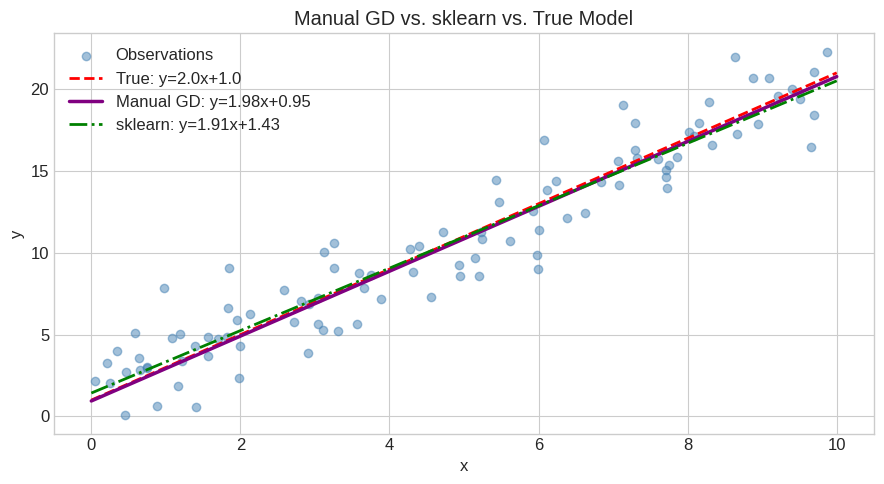

In [ ]:
# ── Step 7: Compare Manual GD vs sklearn LinearRegression ────────────────────
lr_ref = LinearRegression().fit(X.reshape(-1, 1), y)
y_ref  = lr_ref.predict(X.reshape(-1, 1))

print("=== Your Manual Gradient Descent (Step 3) ===")
print(f"  w={w:.6f}  b={b:.6f}")
print(f"  RMSE={rmse(y, w*X+b):.6f}  MAE={mae(y, w*X+b):.6f}")

print("\n=== scikit-learn LinearRegression (Normal Equation) ===")
print(f"  w={lr_ref.coef_[0]:.6f}  b={lr_ref.intercept_:.6f}")
print(f"  RMSE={rmse(y, y_ref):.6f}  MAE={mae(y, y_ref):.6f}")

print(f"\n=== True parameters === w={true_w}  b={true_b}")

plt.figure(figsize=(9, 5))
plt.scatter(X, y, alpha=0.5, color="steelblue", label="Observations", zorder=2)
plt.plot(x_line, true_w*x_line+true_b, "r--", lw=2, label=f"True: y={true_w}x+{true_b}")
plt.plot(x_line, w*x_line+b, "purple", lw=2.5,
         label=f"Manual GD: y={w:.2f}x+{b:.2f}")
plt.plot(x_line, lr_ref.coef_[0]*x_line+lr_ref.intercept_, "green", lw=2, ls="-.",
         label=f"sklearn: y={lr_ref.coef_[0]:.2f}x+{lr_ref.intercept_:.2f}")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Manual GD vs. sklearn vs. True Model")
plt.legend(); plt.tight_layout(); plt.show()

---

### Key Questions

1. Why is it wrong to evaluate the model on the training set only?
2. What happens to the loss if the learning rate is too large? Too small?
3. Why is RMSE more sensitive to outliers than MAE?
4. Why does polynomial degree 12 perfectly fit the training data but fail on the test set?

### Next Lab — Logistic Regression & Classification Metrics

Answers:


1- Because this doesn't let us know how the model will work on new data, what is important to evaluate the performance of the model.

2 - Too large: the vector will not describe the function very properly, it can even be very different. Too small: the vector will follow the shape of the function but it will be slow.

3- ...

4- ...